# Superstore Analysis 

In [1]:
import os
os.getcwd()

'/Users/mihiraryaman/Documents/python_data_analysis_project'

## Data preparation and Cleaning

In [41]:
# uploading the csv to get a pandas data frame object
import pandas as pd 
superstore_df= pd.read_csv('superstore.csv')
superstore_df
#getting the specific columns and shape of the dataframe
superstore_df.columns
#superstore_df.info()
#Checking for null values
superstore_df.isnull().sum().sort_values(ascending=False)
#Checking for duplicate records
superstore_df.duplicated().sum()
superstore_df.columns = superstore_df.columns.str.lower().str.replace('.', '_') 
#replace . with _
superstore_df

# We will be taking some selected columns based on importance for analytics

selected_columns = [
    #Core busisness Martixs
    'sales',
    'profit',
    'quantity',
    'discount',
    'shipping_cost',

    #Time-Based columns
    'order_date',
    'ship_date',
    

    #Customer Columns
    'customer_id',
    'customer_name',
    'segment',
    
    #Product_columns
    'category',
    'sub_category',
    'product_name',
    'product_id',

    #Geographic Columns
    'region',
    'state'

]

survey_df=superstore_df[selected_columns].copy()
survey_df.shape
survey_df.info()
# Mostly object datatype --> mostly strings , can contain mix of few others
# For numeric processing and computations we might need to convert some of the columns into numeric data types  but in our case datypes already have the numeric datatypes
survey_df.describe()
survey_df.sample(10)






<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sales          51290 non-null  int64  
 1   profit         51290 non-null  float64
 2   quantity       51290 non-null  int64  
 3   discount       51290 non-null  float64
 4   shipping_cost  51290 non-null  float64
 5   order_date     51290 non-null  object 
 6   ship_date      51290 non-null  object 
 7   customer_id    51290 non-null  object 
 8   customer_name  51290 non-null  object 
 9   segment        51290 non-null  object 
 10  category       51290 non-null  object 
 11  sub_category   51290 non-null  object 
 12  product_name   51290 non-null  object 
 13  product_id     51290 non-null  object 
 14  region         51290 non-null  object 
 15  state          51290 non-null  object 
dtypes: float64(3), int64(2), object(11)
memory usage: 6.3+ MB


,sales,profit,quantity,discount,shipping_cost,order_date,ship_date,customer_id,customer_name,segment,category,sub_category,product_name,product_id,region,state
49902,24,6.5164,2,0.20,2.560,2012-05-03 00:00:00.000,2012-05-07 00:00:00.000,SV-207854,Stewart Visinsky,Consumer,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,OFF-AP-10003266,East,Pennsylvania
31789,12,-8.9520,2,0.70,2.660,2011-05-09 00:00:00.000,2011-05-12 00:00:00.000,KN-64501,Kean Nguyen,Corporate,Office Supplies,Fasteners,"Accos Clamps, Bulk Pack",OFF-ACC-10001281,Africa,Lagos
13190,8,1.2300,1,0.00,0.690,2011-08-18 00:00:00.000,2011-08-22 00:00:00.000,DS-30302,Darrin Sayre,Home Office,Office Supplies,Envelopes,"Kraft Clasp Envelope, Recycled",OFF-KRA-10002752,EMEA,Tyrol
35768,88,-75.5400,6,0.50,10.176,2014-05-14 00:00:00.000,2014-05-18 00:00:00.000,TT-212203,Thomas Thornton,Consumer,Furniture,Furnishings,"Tenex Door Stop, Black",FUR-FU-10004596,Caribbean,Santo Domingo
47642,20,1.7591,1,0.20,0.940,2012-06-29 00:00:00.000,2012-07-05 00:00:00.000,SC-207254,Steven Cartwright,Consumer,Furniture,Furnishings,"Eldon Executive Woodline II Desk Accessories, ...",FUR-FU-10001473,East,Pennsylvania
32687,3,-1.9650,1,0.50,0.470,2014-06-16 00:00:00.000,2014-06-18 00:00:00.000,MS-177701,Maxwell Schwartz,Consumer,Office Supplies,Binders,"Avery Hole Reinforcements, Durable",OFF-BI-10004334,North Asia,Seoul
48139,147,45.8400,8,0.20,19.710,2013-08-27 00:00:00.000,2013-09-01 00:00:00.000,KD-166154,Ken Dana,Corporate,Office Supplies,Binders,Deluxe Heavy-Duty Vinyl Round Ring Binder,OFF-BI-10001510,East,New York
26229,763,152.6400,2,0.00,85.940,2012-06-26 00:00:00.000,2012-06-26 00:00:00.000,MC-176052,Matt Connell,Corporate,Technology,Copiers,"Hewlett Wireless Fax, Color",TEC-CO-10003800,North,England
38645,65,-0.0636,4,0.27,4.280,2012-10-08 00:00:00.000,2012-10-12 00:00:00.000,JP-154601,Jennifer Patt,Corporate,Furniture,Furnishings,"Rubbermaid Stacking Tray, Erganomic",FUR-FU-10001130,Southeast Asia,Jawa Barat
7284,80,30.4200,9,0.00,9.385,2014-09-26 00:00:00.000,2014-09-28 00:00:00.000,DM-130153,Darrin Martin,Consumer,Office Supplies,Paper,"Eaton Parchment Paper, Recycled",OFF-PA-10001685,Central,Quezaltenango


## Exploratory analysis and Visulization

In [89]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (9,5)
matplotlib.rcParams['figure.facecolor'] = '#00000000'



### Product Analysis

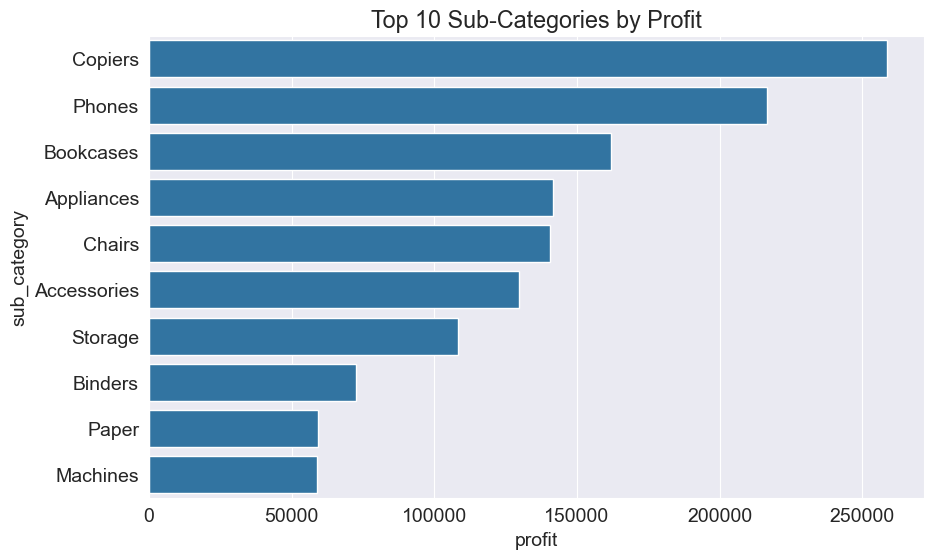

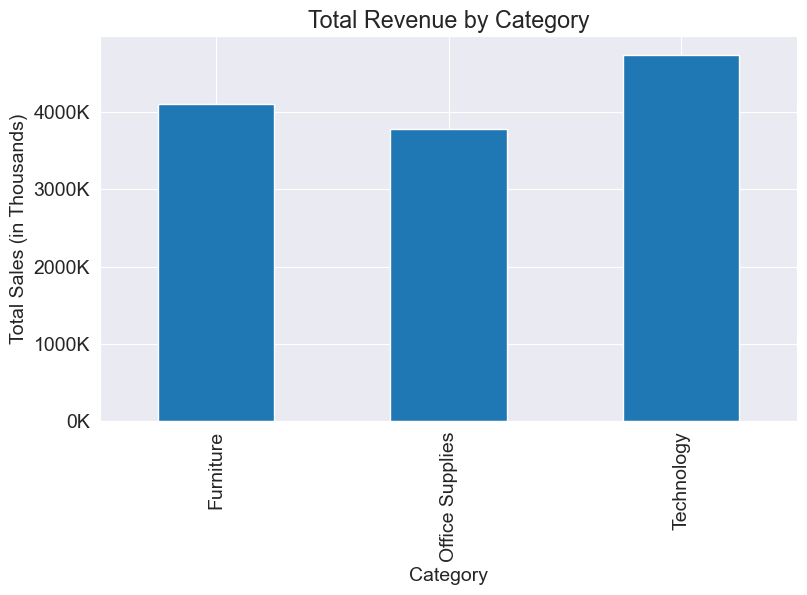

                   sales        profit
category                              
Furniture        4110884  285204.72380
Office Supplies  3787330  518473.83430
Technology       4744691  663778.73318


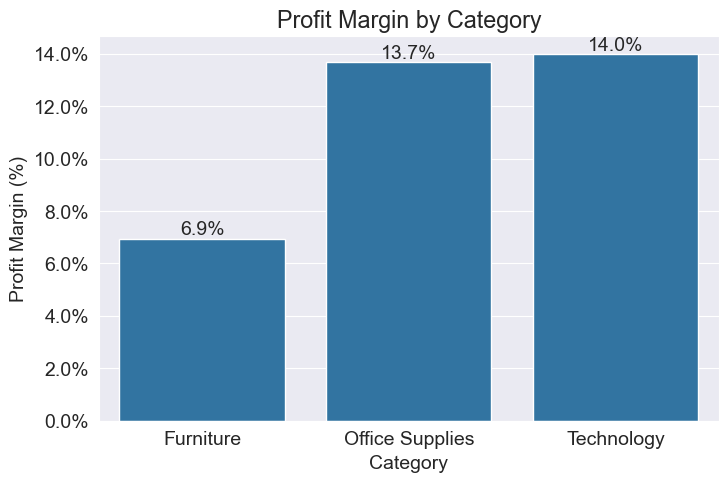

In [109]:
# Analysizing diffrent catergories and Subcategories  of products

# Sub_category Analysis
survey_df.sub_category.count
survey_df.sub_category.unique()
top_sub_category = survey_df.sub_category.value_counts().head(3) 
# top_sub_category are binders Storage and arts 
# getting the total sales and profit by ezch sub_category
subcat_summary = survey_df.groupby('sub_category')[['sales','profit']].sum()
# Adding the profit_margin colums to sub_category summary
subcat_summary['profit_margin_%'] = (
    subcat_summary['profit'] / subcat_summary['sales']
) * 100

subcat_summary = subcat_summary.sort_values(by='sales', ascending=False)
subcat_summary

# Sorting the values the to get the top subcategories
top_profit = subcat_summary.sort_values('profit', ascending=False).head(10).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=top_profit, x='profit', y='sub_category')
plt.title("Top 10 Sub-Categories by Profit")
plt.show()


#Category Analysis
survey_df.category.count
survey_df.category.unique()
top_category = survey_df.category.value_counts().head(2)
# top_category  are office supplies and Technology
category_sales=survey_df.groupby('category')['sales'].sum()
category_sales

# Below  chart will help us in gaining the knowleges that which categories has given how much contributions in sales
fig, ax = plt.subplots()
category_sales.plot(kind='bar', ax=ax)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}K')
)

plt.xlabel("Category")
plt.ylabel("Total Sales (in Thousands)")
plt.title("Total Revenue by Category")
plt.show()
 
# Below describes the profit margin for each category
category_summary = survey_df.groupby('category')[['sales', 'profit']].sum()
print(category_summary)
 # deducing the profit margin by category
category_summary['profit_Margin_%'] = (
    category_summary['profit'] / category_summary['sales']
) * 100

category_summary_reset = category_summary.reset_index()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=category_summary_reset,
    x='category',
    y='profit_Margin_%'
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

# Format y-axis as percentage
ax.yaxis.set_major_formatter(ticker.PercentFormatter())

# Add value labels on bars
for i in range(len(category_summary_reset)):
    value = category_summary_reset['profit_Margin_%'][i]
    ax.text(i, value, f"{value:.1f}%", ha='center', va='bottom')

plt.show()










#### Core Business Matrix Analysis

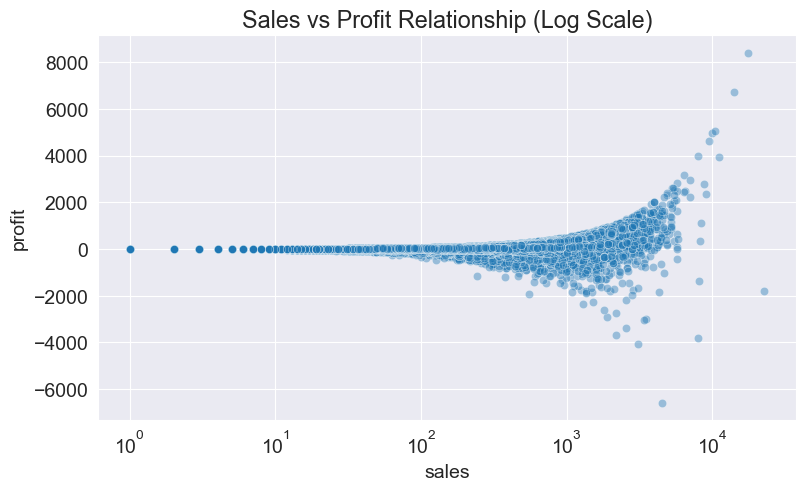

/var/folders/qp/96h3cs2j25gb_ly7j8pssv3w0000gn/T/ipykernel_39339/2688063706.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['sales'].corr(x['profit']))
/opt/miniconda3/envs/data_analysis/lib/python3.11/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/miniconda3/envs/data_analysis/lib/python3.11/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


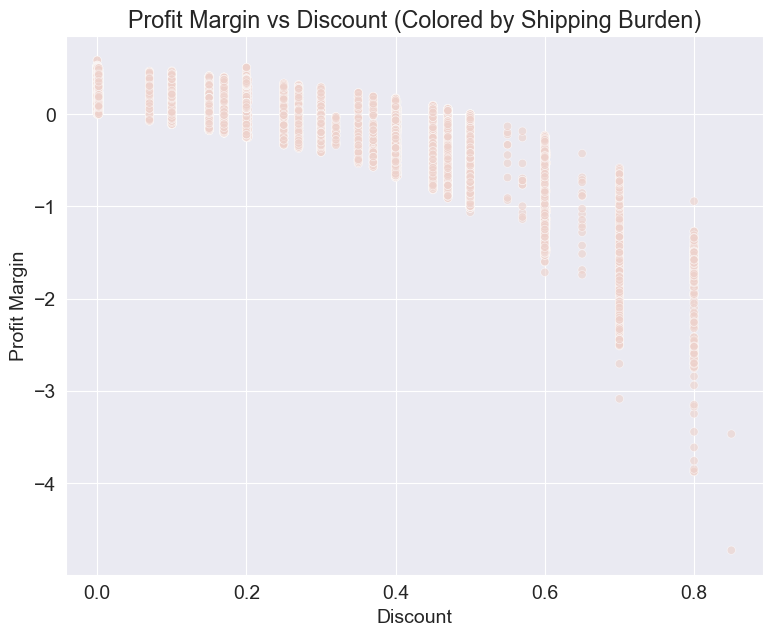

In [ ]:
# Analysizing the columns like sales ,profit ,quantity , discounts and shipping costs

# Revenue vs Profit analysis
survey_df['profit_margin'] = (survey_df['profit'] / survey_df['sales']) * 100
survey_df.profit_margin.head(10)

#Analysizing the sales vs profit distribution
sns.scatterplot(
    data=survey_df,
    x='sales',
    y='profit',
    alpha=0.4
)

plt.xscale('log')   #  add this

plt.title('Sales vs Profit Relationship (Log Scale)')
plt.show()

# Through below plot we can derive the inference 
# The log-scale visualization reveals increasing profit volatility with higher sales values. 
# While overall profitability trends upward, 
# the presence of high-value loss-making transactions suggests inconsistent margin control on bulk orders.
#  This indicates an opportunity to optimize discount policies, shipping cost allocation, and pricing strategy for large transactions

# Correlation by sub_categories  
# 0 + (~ to 1) mean high sales means highly scalable with increased sales 
# (~ close to 0) means Non- consist relationship
# Negative values indicate that Higher sales leads to losses
corr_by_subcat = (
    survey_df.groupby('sub_category')
      .apply(lambda x: x['sales'].corr(x['profit']))
      .reset_index(name='sales_profit_corr')
      .sort_values(by='sales_profit_corr', ascending=False)
)

corr_by_subcat

# Discount correlations
survey_df[['discount','profit']].corr()
# The relation came out to be -0.316 moderately negative correlation
# Discounts are hurting profits

# Shipping cost correlations
survey_df[['shipping_cost','profit']].corr()

#Have higher sales
#Naturally have higher shipping cost
#But still generate profit
#So shipping cost is acting as a proxy for order size, not a cost problem.

survey_df[['quantity','profit']].corr()

#Increasing quantity does NOT strongly increase profit.
# Selling more units does not guarantee higher profitability.

survey_df['profit_margin'] = survey_df['profit'] / survey_df['sales']
survey_df['shipping_ratio'] = survey_df['shipping_cost'] / survey_df['sales']

plt.figure(figsize=(9,7))

sns.scatterplot(
    data=survey_df,
    x='discount',
    y='profit_margin',
    hue='shipping_ratio',
    alpha=0.6
)

plt.title('Profit Margin vs Discount (Colored by Shipping Burden)')
plt.xlabel('Discount')
plt.ylabel('Profit Margin')

plt.show()





#### Geographic Analysis 

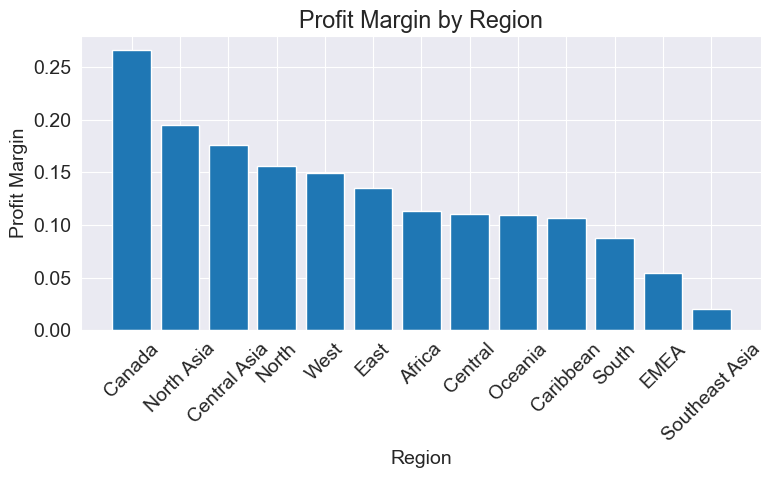

,region,sales,profit,profit_margin
1,Canada,66932,17817.39000,0.266201
8,North Asia,848349,165578.42100,0.195177
4,Central Asia,752839,132480.18700,0.175974
7,North,1248192,194597.95252,0.155904
12,West,725514,108418.44890,0.149437
6,East,678834,91522.78000,0.134824
0,Africa,783776,88871.63100,0.113389
3,Central,2822399,311403.98164,0.110333
9,Oceania,1100207,120089.11200,0.109151
2,Caribbean,324281,34571.32104,0.106609


In [ ]:
# Group by Region
region_summary = (
    survey_df.groupby('region')
      .agg({'sales': 'sum', 'profit': 'sum'})
      .reset_index()
)

# Calculate Profit Margin
region_summary['profit_margin'] = region_summary['profit'] / region_summary['sales']

# Sort by Profit Margin (Highest first)
region_summary = region_summary.sort_values(by='profit_margin', ascending=False)
#abc
# Plot
plt.figure(figsize=(8,5))
plt.bar(region_summary['region'], region_summary['profit_margin'])

plt.xlabel('Region')
plt.ylabel('Profit Margin')
plt.title('Profit Margin by Region')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Display table
region_summary